# Bare-Model Rectified Flow Inversion (InstaFlow)

This notebook implements **flow inversion** with bare modules only:
- `UNet2DConditionModel`
- `AutoencoderKL`
- `CLIPTokenizer` and `CLIPTextModel`

No custom pipeline call is used for inference.

The core update follows your repository (`instaflow/pipeline_rf.py`):
- Forward generation: `x <- x + dt * v(x, t)`
- Inversion: `x <- x - dt * v(x, t)`

You can test either:
1. Generated sample inversion-reconstruction (sanity check)
2. Real image inversion-reconstruction (edit `REAL_IMAGE_PATH`)

In [16]:
# Environment check (run once)
import os
import sys
import torch

print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Python: 3.11.14
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA RTX 4000 Ada Generation


In [21]:
import math
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# Keep the same precision style as drag.ipynb
DTYPE = torch.bfloat16 if DEVICE == "cuda" else torch.float32

# Reuse the exact checkpoint family used in drag.ipynb
MODEL_ID = "XCLiu/2_rectified_flow_from_sd_1_5"
LOCAL_FILES_ONLY = True  # Prevent any new download; use local cache only

HEIGHT = 512
WIDTH = 512
N_STEPS = 50
GUIDANCE_SCALE = 3.0
NEG_PROMPT = ""

PROMPT = "a cinematic photo of a lighthouse on a rocky coast at sunset, volumetric lighting, ultra detailed"
REAL_IMAGE_PATH = None  # e.g. "assets/my_image.png"

load_kwargs = {
    "torch_dtype": DTYPE,
    "local_files_only": LOCAL_FILES_ONLY,
}
if DEVICE == "cuda":
    load_kwargs["device_map"] = "cuda"

print(f"DEVICE={DEVICE}, DTYPE={DTYPE}, N_STEPS={N_STEPS}")
print(f"MODEL_ID={MODEL_ID}, LOCAL_FILES_ONLY={LOCAL_FILES_ONLY}")

DEVICE=cuda, DTYPE=torch.bfloat16, N_STEPS=50
MODEL_ID=XCLiu/2_rectified_flow_from_sd_1_5, LOCAL_FILES_ONLY=True


In [22]:
# Load using the same entry point as drag.ipynb, then reuse bare modules
from instaflow.pipeline_edit import RectifiedFlowStateMachine

pipe = RectifiedFlowStateMachine.from_pretrained(MODEL_ID, **load_kwargs)
pipe.safety_checker = None

# Bare modules reused from the loaded pipeline
tokenizer = pipe.tokenizer
text_encoder = pipe.text_encoder
vae = pipe.vae
unet = pipe.unet

text_encoder.eval()
vae.eval()
unet.eval()

VAE_SCALING = vae.config.scaling_factor
print("Loaded from drag-compatible checkpoint:", MODEL_ID)
print("VAE scaling_factor:", VAE_SCALING)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /Data/yiming.chen/huggingface/hub/models--XCLiu--2_rectified_flow_from_sd_1_5/snapshots/934962eb1054b67883fabb3e0860b851baf31142/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /Data/yiming.chen/huggingface/hub/models--XCLiu--2_rectified_flow_from_sd_1_5/snapshots/934962eb1054b67883fabb3e0860b851baf31142/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded from drag-compatible checkpoint: XCLiu/2_rectified_flow_from_sd_1_5
VAE scaling_factor: 0.18215


In [23]:
@torch.no_grad()
def encode_prompt(prompt: str, negative_prompt: str = "", do_cfg: bool = True):
    text_in = tokenizer(
        prompt,
        padding="max_length",
        max_length=tokenizer.model_max_length,
        truncation=True,
        return_tensors="pt",
    )
    pos = text_encoder(text_in.input_ids.to(DEVICE))[0]

    if not do_cfg:
        return pos

    neg_in = tokenizer(
        negative_prompt,
        padding="max_length",
        max_length=tokenizer.model_max_length,
        truncation=True,
        return_tensors="pt",
    )
    neg = text_encoder(neg_in.input_ids.to(DEVICE))[0]
    return torch.cat([neg, pos], dim=0)


@torch.no_grad()
def pil_to_latent(img_pil: Image.Image):
    img = img_pil.convert("RGB").resize((WIDTH, HEIGHT), Image.Resampling.LANCZOS)
    x = np.array(img).astype(np.float32) / 255.0
    x = (x * 2.0 - 1.0).transpose(2, 0, 1)
    x = torch.from_numpy(x).unsqueeze(0).to(device=DEVICE, dtype=DTYPE)
    lat = vae.encode(x).latent_dist.sample() * VAE_SCALING
    return lat


@torch.no_grad()
def latent_to_pil(latent: torch.Tensor):
    x = vae.decode(latent / VAE_SCALING, return_dict=False)[0]
    x = (x / 2 + 0.5).clamp(0, 1)
    x = x[0].detach().float().cpu().permute(1, 2, 0).numpy()
    return Image.fromarray((x * 255).astype(np.uint8))


@torch.no_grad()
def rf_velocity(x_t: torch.Tensor, t_scalar: float, prompt_embeds: torch.Tensor, do_cfg: bool, guidance_scale: float):
    latent_model_input = torch.cat([x_t] * 2) if do_cfg else x_t
    vec_t = torch.full((latent_model_input.shape[0],), float(t_scalar), device=DEVICE, dtype=latent_model_input.dtype)

    out = unet(latent_model_input, vec_t, encoder_hidden_states=prompt_embeds)
    v = out.sample if hasattr(out, "sample") else out[0]

    if do_cfg:
        v_neg, v_pos = v.chunk(2)
        v = v_neg + guidance_scale * (v_pos - v_neg)
    return v


@torch.no_grad()
def rf_forward_from_noise(z0: torch.Tensor, prompt_embeds: torch.Tensor, n_steps: int, do_cfg: bool, guidance_scale: float):
    # Match repository schedule in instaflow/pipeline_rf.py
    timesteps = [(1.0 - i / n_steps) * 1000.0 for i in range(n_steps)]
    dt = 1.0 / n_steps

    x = z0.clone()
    traj = [x.clone()]
    for t in timesteps:
        v = rf_velocity(x, t, prompt_embeds, do_cfg, guidance_scale)
        x = x + dt * v
        traj.append(x.clone())
    return x, traj


@torch.no_grad()
def rf_invert_to_noise(x1: torch.Tensor, prompt_embeds: torch.Tensor, n_steps: int, do_cfg: bool, guidance_scale: float):
    # Reverse Euler on the same ODE: x <- x - dt * v(x, t)
    timesteps = [(1.0 - i / n_steps) * 1000.0 for i in range(n_steps)]
    dt = 1.0 / n_steps

    x = x1.clone()
    traj = [x.clone()]
    for t in reversed(timesteps):
        v = rf_velocity(x, t, prompt_embeds, do_cfg, guidance_scale)
        x = x - dt * v
        traj.append(x.clone())
    return x, traj


def mse_psnr(a: np.ndarray, b: np.ndarray):
    a = a.astype(np.float32) / 255.0
    b = b.astype(np.float32) / 255.0
    mse = float(np.mean((a - b) ** 2))
    psnr = 20.0 * math.log10(1.0 / math.sqrt(max(mse, 1e-12)))
    return mse, psnr

Demo A metrics
MSE  : 0.012502
PSNR : 19.03 dB


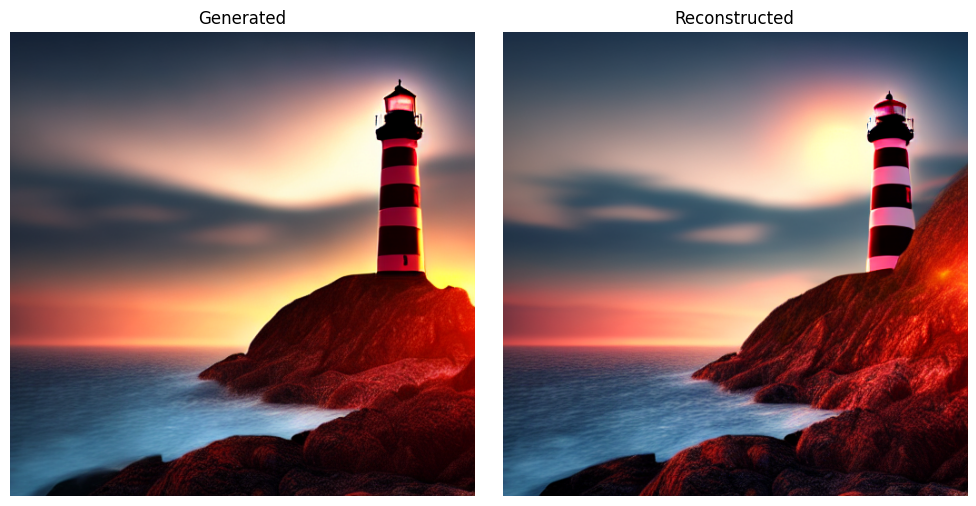

In [25]:
# Demo A: self-consistency (sample -> invert -> reconstruct)
do_cfg = GUIDANCE_SCALE > 1.0
prompt_embeds = encode_prompt(PROMPT, NEG_PROMPT, do_cfg=do_cfg)

# Start from Gaussian noise and generate image latent
z0 = torch.randn((1, unet.config.in_channels, HEIGHT // 8, WIDTH // 8), device=DEVICE, dtype=DTYPE)
x_gen, _ = rf_forward_from_noise(z0, prompt_embeds, N_STEPS, do_cfg, GUIDANCE_SCALE)
img_gen = latent_to_pil(x_gen)

# Invert generated latent back to noise, then regenerate
z_inv, _ = rf_invert_to_noise(x_gen, prompt_embeds, N_STEPS, do_cfg, GUIDANCE_SCALE)
x_rec, _ = rf_forward_from_noise(z_inv, prompt_embeds, N_STEPS, do_cfg, GUIDANCE_SCALE)
img_rec = latent_to_pil(x_rec)

arr_gen = np.array(img_gen)
arr_rec = np.array(img_rec)
mse_a, psnr_a = mse_psnr(arr_gen, arr_rec)

print("Demo A metrics")
print(f"MSE  : {mse_a:.6f}")
print(f"PSNR : {psnr_a:.2f} dB")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(arr_gen)
axes[0].set_title("Generated")
axes[0].axis("off")
axes[1].imshow(arr_rec)
axes[1].set_title("Reconstructed")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [15]:
# Demo B (optional): real image inversion-reconstruction
# Set REAL_IMAGE_PATH above before running this cell.
if REAL_IMAGE_PATH is None:
    print("Skip Demo B. Set REAL_IMAGE_PATH to enable real-image inversion.")
else:
    p = Path(REAL_IMAGE_PATH)
    assert p.exists(), f"Image not found: {p}"

    img_real = Image.open(p).convert("RGB").resize((WIDTH, HEIGHT), Image.Resampling.LANCZOS)
    x_real = pil_to_latent(img_real)

    do_cfg_b = GUIDANCE_SCALE > 1.0
    prompt_embeds_b = encode_prompt(PROMPT, NEG_PROMPT, do_cfg=do_cfg_b)

    z_real_inv, _ = rf_invert_to_noise(x_real, prompt_embeds_b, N_STEPS, do_cfg_b, GUIDANCE_SCALE)
    x_real_rec, _ = rf_forward_from_noise(z_real_inv, prompt_embeds_b, N_STEPS, do_cfg_b, GUIDANCE_SCALE)

    img_real_rec = latent_to_pil(x_real_rec)

    arr_real = np.array(img_real)
    arr_real_rec = np.array(img_real_rec)
    mse_b, psnr_b = mse_psnr(arr_real, arr_real_rec)

    print("Demo B metrics")
    print(f"MSE  : {mse_b:.6f}")
    print(f"PSNR : {psnr_b:.2f} dB")

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(arr_real)
    axes[0].set_title("Real Input")
    axes[0].axis("off")
    axes[1].imshow(arr_real_rec)
    axes[1].set_title("Reconstructed")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

Skip Demo B. Set REAL_IMAGE_PATH to enable real-image inversion.
